# 16 -- PAE K=5 Full Analysis: VIM-Retained Breast CyTOF

Analysis of K=5 PAE trained on the full dataset **with VIM-high cells retained**.

**Model:** `outputs/breast_pae_withvim_k5` (best seed auto-selected by val loss)  
**Data:** `data/breast_cytof_withvim_processed.h5ad` (150k cells, 10k/sample, no VIM filter)  
**Clinical:** BreastMS_tables.xlsx Table S2  
**Report:** `reports/k5_withvim_pae/`

> Run notebook 15 first to generate the model outputs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

REPO_ROOT  = Path('../../')
OUTPUT_DIR = REPO_ROOT / 'outputs/breast_pae_withvim_k5'
RUN_BASE   = OUTPUT_DIR / 'runs/probabilistic_archetypal_ae/dim_05'
H5AD_PATH  = REPO_ROOT / 'data/breast_cytof_withvim_processed.h5ad'
OUT_DIR    = REPO_ROOT / 'reports/k5_withvim_pae'
FIG_DIR    = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Pick best seed by validation loss
best_seed, best_val = None, float('inf')
for seed_dir in sorted(RUN_BASE.iterdir()):
    hf = seed_dir / 'training_history.csv'
    if hf.exists():
        h = pd.read_csv(hf)
        v = h['val_loss'].min()
        print(f'  {seed_dir.name}: val_loss={v:.4f}')
        if v < best_val:
            best_val, best_seed = v, seed_dir
print(f'\nBest seed: {best_seed.name}  val_loss={best_val:.4f}')
RUN_DIR = best_seed

# Clinical metadata from BreastMS_tables.xlsx Table S2
CLINICAL = {
    '4':   {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.91,'tumor_type':'IDC','age':61,'note':''},
    '4.1': {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.91,'tumor_type':'IDC','age':61,'note':'replicate'},
    '5':   {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.96,'tumor_type':'IDC','age':87,'note':'elderly'},
    '7':   {'subtype':'LUM B','grade':3,'ki67':0.40,'er':0.86,'tumor_type':'IDC','age':37,'note':'young (37y)'},
    '7.1': {'subtype':'LUM B','grade':3,'ki67':0.40,'er':0.86,'tumor_type':'IDC','age':37,'note':'replicate'},
    '8':   {'subtype':'LUM A','grade':2,'ki67':0.10,'er':0.93,'tumor_type':'ILC','age':46,'note':'CDH1 Y523*'},
    '8.1': {'subtype':'LUM A','grade':2,'ki67':0.10,'er':0.93,'tumor_type':'ILC','age':46,'note':'replicate'},
    '11':  {'subtype':'TN',   'grade':3,'ki67':0.90,'er':0.05,'tumor_type':'IDC','age':76,'note':'TP53 c.375+1delG'},
    '13':  {'subtype':'LUM B','grade':3,'ki67':0.50,'er':0.77,'tumor_type':'IDC','age':73,'note':'BRCA1; 47% basal'},
    '14':  {'subtype':'LUM B','grade':3,'ki67':0.50,'er':0.85,'tumor_type':'IDC','age':64,'note':'TP53; 53% basal'},
    '15':  {'subtype':'LUM A','grade':2,'ki67':0.25,'er':0.87,'tumor_type':'IDC','age':63,'note':'PIK3CA E545K'},
    '17':  {'subtype':'LUM B','grade':3,'ki67':0.80,'er':0.73,'tumor_type':'IDC','age':62,'note':'TP53+PIK3CA'},
    '18':  {'subtype':'LUM A','grade':2,'ki67':0.40,'er':0.93,'tumor_type':'IDC','age':67,'note':''},
    '19':  {'subtype':'LUM A','grade':2,'ki67':0.20,'er':0.76,'tumor_type':'IDC','age':44,'note':'PIK3CA H1047R'},
    '20':  {'subtype':'LUM A','grade':2,'ki67':0.20,'er':0.90,'tumor_type':'IDC','age':69,'note':'PIK3CA H1047R'},
}
SUBTYPE_COLORS = {'LUM A':'#4393c3','LUM B':'#d6604d','TN':'#111111','ILC':'#74c476'}

matplotlib.rcParams.update({
    'font.family':'sans-serif','font.size':10,
    'axes.titlesize':11,'axes.labelsize':10,
    'xtick.labelsize':9,'ytick.labelsize':9,
    'figure.dpi':150,'savefig.dpi':200,'savefig.bbox':'tight',
})
print('Setup complete. OUT_DIR:', OUT_DIR)


  seed_123: val_loss=25.3953
  seed_42: val_loss=25.6362
  seed_456: val_loss=26.2055

Best seed: seed_123  val_loss=25.3953
Setup complete. OUT_DIR: ../../reports/k5_withvim_pae


In [2]:
import anndata as ad

adata = ad.read_h5ad(H5AD_PATH)
print(f'h5ad: {adata.shape[0]:,} cells x {adata.shape[1]} markers')
print(f'Samples: {sorted(adata.obs["sample_id"].unique())}')

cm = pd.read_csv(RUN_DIR / 'component_means.csv', index_col=0)
cv = pd.read_csv(RUN_DIR / 'component_vars.csv', index_col=0)
K = len(cm)
W_COLS = [f'w_{i}' for i in range(K)]
MARKERS = list(cm.columns)
ARCHETYPE_COLORS = sns.color_palette('tab10', K)

hist = pd.read_csv(RUN_DIR / 'training_history.csv')
print(f'Training: {len(hist)} epochs  best val_loss={hist["val_loss"].min():.4f} '
      f'at epoch {int(hist["val_loss"].idxmin())}')

# Auto-characterize archetypes from top/bottom markers
print('\n=== Archetype auto-characterization (top markers) ===')
for comp in cm.index:
    top = cm.loc[comp].sort_values(ascending=False)
    bot = cm.loc[comp].sort_values()
    print(f'\n{comp}:')
    print(f'  HIGH: {", ".join(f"{m}({v:+.2f})" for m,v in top.head(6).items())}')
    print(f'  LOW:  {", ".join(f"{m}({v:+.2f})" for m,v in bot.head(4).items())}')

# ---- EDIT THESE NAMES AFTER REVIEWING THE AUTO-CHARACTERIZATION ABOVE ----
COMP_NAMES = [
    'A0: TBD',
    'A1: TBD',
    'A2: TBD',
    'A3: TBD',
    'A4: TBD',
]
# Update indices after running next cell to set biological labels
cm.index = [f'component_{i}' for i in range(K)]
cv.index = [f'component_{i}' for i in range(K)]


h5ad: 150,000 cells x 31 markers
Samples: ['11', '13', '14', '15', '17', '18', '19', '20', '4', '4.1', '5', '7', '7.1', '8', '8.1']
Training: 753 epochs  best val_loss=25.3953 at epoch 737

=== Archetype auto-characterization (top markers) ===

component_0:
  HIGH: H3S28p(+3.56), CD24(+3.17), H3K64ac(+3.04), H3K36me3(+2.91), H3K9me3(+2.66), H3K27me3(+2.64)
  LOW:  aSMA(-3.06), EZH2(-2.60), K5(-2.35), panKeratin(-2.19)

component_1:
  HIGH: K8-18(+3.71), panKeratin(+3.47), H4K20me3(+2.16), aSMA(+2.09), ER(+1.85), CD24(+0.97)
  LOW:  H3K64ac(-2.98), H3K27me2(-2.55), H4K16ac(-2.53), H3K27ac(-2.50)

component_2:
  HIGH: aSMA(+4.88), K5(+3.80), H3K9me2(+2.46), H3K4me3(+2.17), H3K4me1(+1.76), CD44(+1.45)
  LOW:  K8-18(-4.66), H4K20me3(-2.46), GATA3(-2.12), panKeratin(-1.70)

component_3:
  HIGH: EZH2(+2.51), Ki67(+0.70), EpCam(+0.35), H3K27me2(+0.34), CD49f(+0.25), K8-18(-0.29)
  LOW:  aSMA(-4.32), H3K36me3(-4.08), H3K9me2(-3.82), ER(-3.26)

component_4:
  HIGH: H3K27me2(+5.01), H3K36me2(+4.

In [3]:
# === ASSIGN BIOLOGICAL ARCHETYPE NAMES ===
# Review the auto-characterization printout above, then edit here.
# VIM is present in the data -- one archetype should capture VIM-high stromal/mesenchymal cells.

# Default placeholder -- MUST BE UPDATED after reviewing component means
COMP_NAMES = [
    'A0: Luminal progenitor (CD24-high)',
    'A1: Mature luminal epithelial',
    'A2: VIM-high mesenchymal/EMT (TNBC-like)',
    'A3: EZH2-high proliferative luminal',
    'A4: Luminal-B bivalent epigenetic',
]

# After running and seeing the component means, update like this example:
# COMP_NAMES = [
#     'A0: Luminal A (mature)',
#     'A1: VIM-high stromal/CAF',
#     'A2: Luminal progenitor',
#     'A3: EZH2-high aggressive',
#     'A4: Luminal B (bivalent)',
# ]

cm.index = COMP_NAMES
cv.index = COMP_NAMES
print('Archetype names set:')
for n in COMP_NAMES:
    print(f'  {n}')

# Merge all splits
dfs = []
for split in ['train', 'val', 'test']:
    wf = RUN_DIR / split / 'weights.csv'
    if wf.exists():
        df = pd.read_csv(wf, index_col=0)
        df['split'] = split
        dfs.append(df)
all_w = pd.concat(dfs).join(adata.obs[['sample_id']])
all_w['dominant'] = all_w[W_COLS].values.argmax(axis=1)
print(f'\nWeights: {len(all_w):,} total, {all_w["sample_id"].notna().sum():,} matched to h5ad')

per_sample_mean = all_w.groupby('sample_id', observed=True)[W_COLS].mean()
per_sample_mean.columns = COMP_NAMES

per_sample_dom = (all_w.groupby('sample_id', observed=True)['dominant']
                  .value_counts(normalize=True).unstack(fill_value=0))
per_sample_dom.columns = [COMP_NAMES[c] for c in per_sample_dom.columns]

sample_counts = adata.obs['sample_id'].value_counts()
sample_order  = sorted(per_sample_mean.index, key=lambda x: float(x))

print('\nPer-sample dominant archetype:')
for s in sample_order:
    row = per_sample_dom.loc[s]
    dom = row.idxmax(); frac = row.max()
    c = CLINICAL.get(str(s), {})
    print(f"  S{s}: {dom}  ({frac:.1%})  [{c.get('subtype','?')} G{c.get('grade','?')} Ki67={c.get('ki67',0):.0%}]")


Archetype names set:
  A0: Luminal progenitor (CD24-high)
  A1: Mature luminal epithelial
  A2: VIM-high mesenchymal/EMT (TNBC-like)
  A3: EZH2-high proliferative luminal
  A4: Luminal-B bivalent epigenetic

Weights: 150,000 total, 45,000 matched to h5ad

Per-sample dominant archetype:
  S4: A1: Mature luminal epithelial  (82.3%)  [LUM A G2 Ki67=30%]
  S4.1: A1: Mature luminal epithelial  (82.5%)  [LUM A G2 Ki67=30%]
  S5: A4: Luminal-B bivalent epigenetic  (45.8%)  [LUM A G2 Ki67=30%]
  S7: A0: Luminal progenitor (CD24-high)  (36.2%)  [LUM B G3 Ki67=40%]
  S7.1: A1: Mature luminal epithelial  (30.4%)  [LUM B G3 Ki67=40%]
  S8: A1: Mature luminal epithelial  (52.7%)  [LUM A G2 Ki67=10%]
  S8.1: A1: Mature luminal epithelial  (52.2%)  [LUM A G2 Ki67=10%]
  S11: A2: VIM-high mesenchymal/EMT (TNBC-like)  (57.4%)  [TN G3 Ki67=90%]
  S13: A3: EZH2-high proliferative luminal  (28.6%)  [LUM B G3 Ki67=50%]
  S14: A1: Mature luminal epithelial  (34.7%)  [LUM B G3 Ki67=50%]
  S15: A1: Mature lum

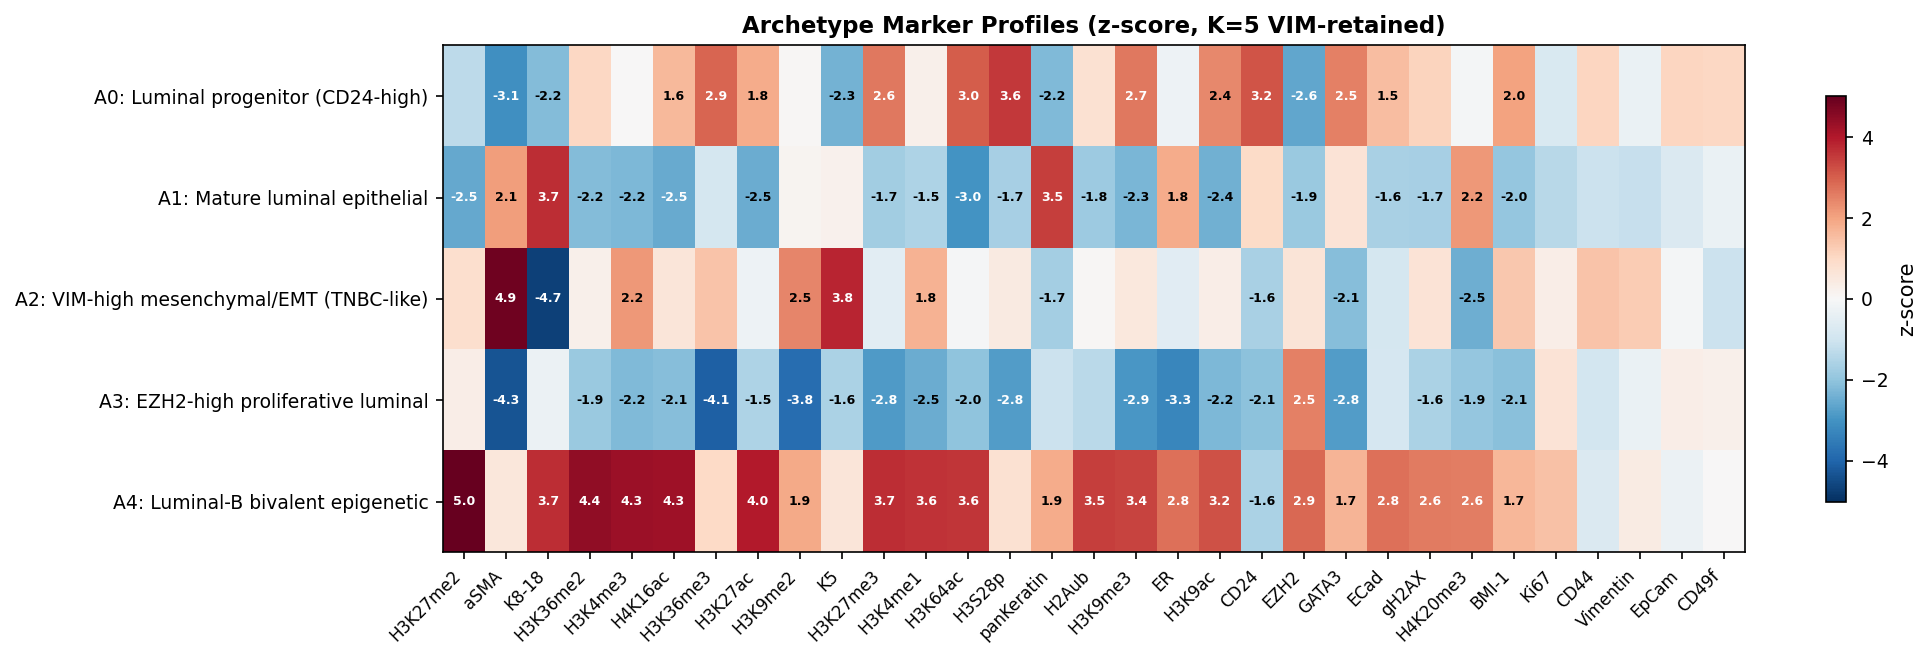

Saved fig1


In [4]:
# Figure 1: Archetype marker profiles heatmap
fig, ax = plt.subplots(figsize=(14, 4.5))
marker_order = cm.abs().max(axis=0).sort_values(ascending=False).index.tolist()
cm_ord = cm[marker_order]
vmax = max(abs(cm.values.min()), abs(cm.values.max()))
im = ax.imshow(cm_ord.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(marker_order)))
ax.set_xticklabels(marker_order, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels(COMP_NAMES, fontsize=9)
ax.set_title('Archetype Marker Profiles (z-score, K=5 VIM-retained)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.8)
for i in range(K):
    for j, m in enumerate(marker_order):
        val = cm_ord.iloc[i, j]
        if abs(val) > 1.5:
            color = 'white' if abs(val) > 2.5 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6, color=color, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.png')
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.pdf')
plt.show(); print('Saved fig1')

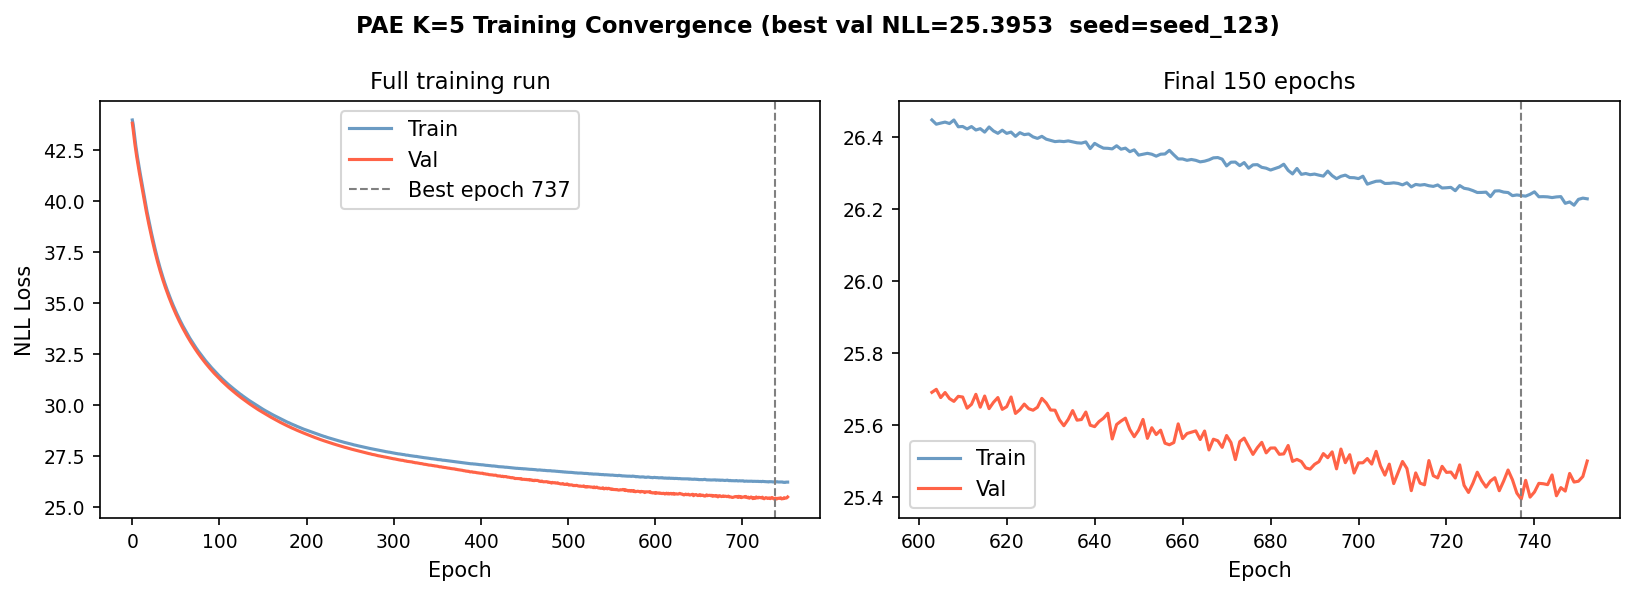

Saved fig2


In [5]:
# Figure 2: Training convergence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
best_epoch = int(hist['val_loss'].idxmin())
axes[0].plot(hist.index, hist['train_loss'], label='Train', color='steelblue', lw=1.5, alpha=0.8)
axes[0].plot(hist.index, hist['val_loss'], label='Val', color='tomato', lw=1.5)
axes[0].axvline(best_epoch, color='gray', ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL Loss'); axes[0].set_title('Full training run'); axes[0].legend()
tail = hist.tail(150)
axes[1].plot(tail.index, tail['train_loss'], color='steelblue', lw=1.5, alpha=0.8, label='Train')
axes[1].plot(tail.index, tail['val_loss'], color='tomato', lw=1.5, label='Val')
axes[1].axvline(best_epoch, color='gray', ls='--', lw=1); axes[1].set_xlabel('Epoch')
axes[1].set_title('Final 150 epochs'); axes[1].legend()
fig.suptitle(f'PAE K=5 Training Convergence (best val NLL={hist["val_loss"].min():.4f}  seed={RUN_DIR.name})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_convergence.png')
fig.savefig(FIG_DIR / 'fig2_training_convergence.pdf')
plt.show(); print('Saved fig2')

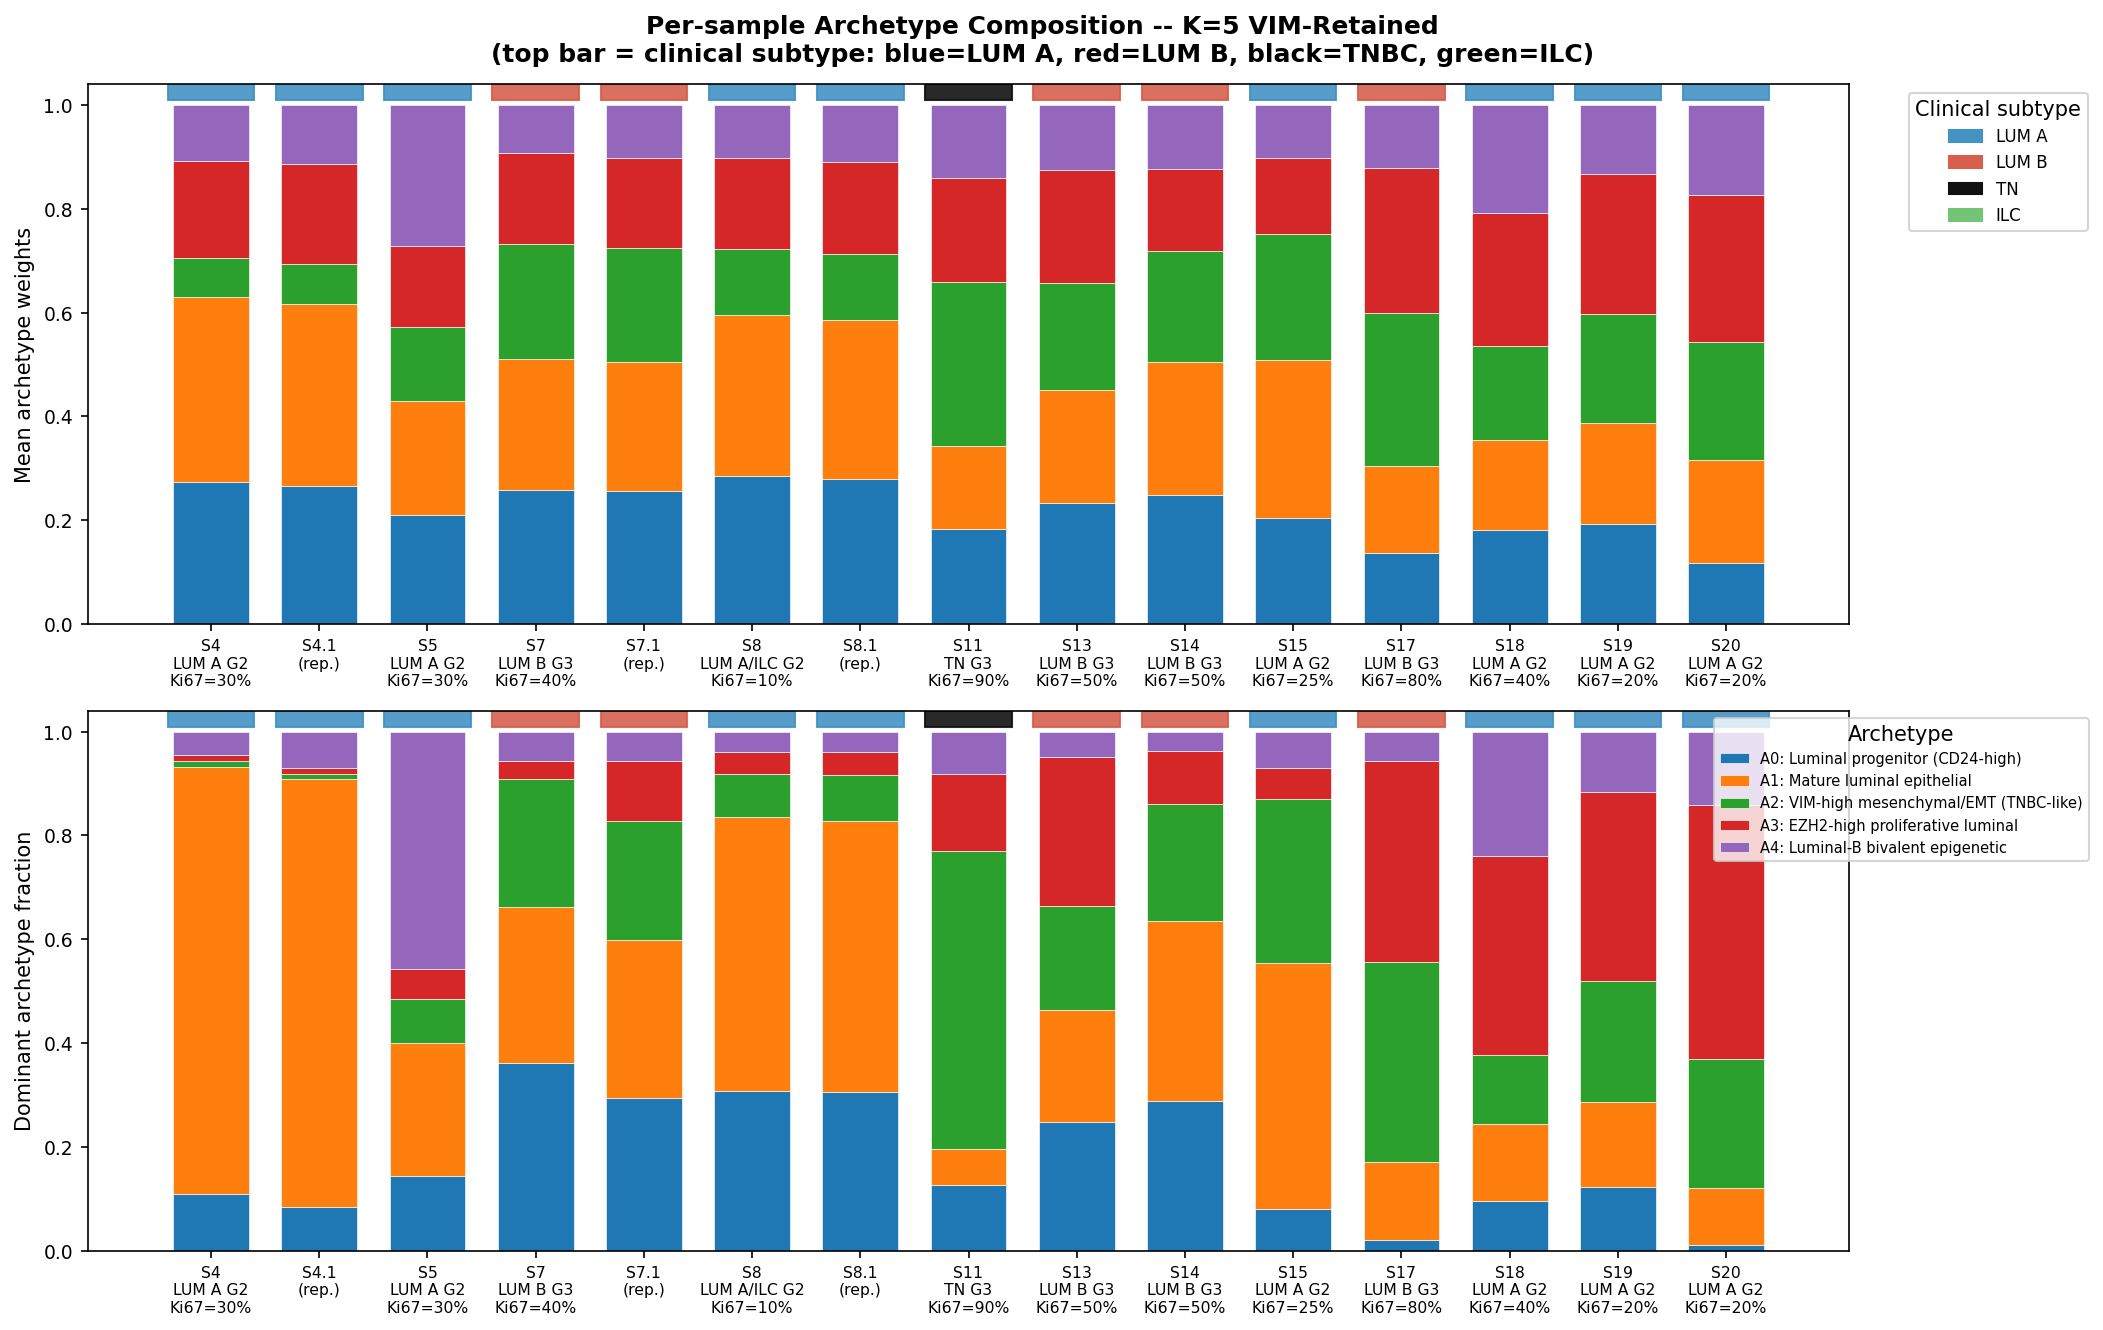

Saved fig3


In [6]:
# Figure 3: Per-sample composition with clinical annotation
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
psmean = per_sample_mean.loc[sample_order]
psdom  = per_sample_dom.reindex(sample_order)
x = np.arange(len(sample_order))

def make_xlabels(order):
    labels = []
    for sid in order:
        c = CLINICAL.get(str(sid), {})
        sub = c.get('subtype','?'); tt = c.get('tumor_type','IDC')
        g = c.get('grade','?'); ki = c.get('ki67',0); note = c.get('note','')
        if 'replicate' in note:
            labels.append(f'S{sid}\n(rep.)')
        else:
            lbl = f'S{sid}\n{sub}'
            if tt == 'ILC': lbl += '/ILC'
            lbl += f' G{g}\nKi67={ki:.0%}'
            labels.append(lbl)
    return labels

xlabels = make_xlabels(sample_order)
bar_top_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]

for ax_i, (data, title) in enumerate([(psmean,'Mean archetype weights'),(psdom,'Dominant archetype fraction')]):
    ax = axes[ax_i]; bottom = np.zeros(len(sample_order))
    for comp, color in zip(COMP_NAMES, ARCHETYPE_COLORS):
        vals = data[comp].fillna(0).values if comp in data.columns else np.zeros(len(sample_order))
        ax.bar(x, vals, bottom=bottom, color=color, label=comp, width=0.7, edgecolor='white', linewidth=0.3)
        bottom += vals
    for xi, col in enumerate(bar_top_colors):
        ax.axvspan(xi-0.4, xi+0.4, ymin=0.97, ymax=1.0, color=col, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=7.5)
    ax.set_ylim(0, 1.04); ax.set_ylabel(title)
    if ax_i == 1:
        ax.legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.14, 1.0), title='Archetype')
from matplotlib.patches import Patch
legend_subtypes = [Patch(color=v, label=k) for k, v in SUBTYPE_COLORS.items()]
axes[0].legend(handles=legend_subtypes, loc='upper right', fontsize=8,
               bbox_to_anchor=(1.14, 1.0), title='Clinical subtype')
fig.suptitle('Per-sample Archetype Composition -- K=5 VIM-Retained\n'
             '(top bar = clinical subtype: blue=LUM A, red=LUM B, black=TNBC, green=ILC)',
             fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_sample_composition.png'); fig.savefig(FIG_DIR / 'fig3_sample_composition.pdf')
plt.show(); print('Saved fig3')

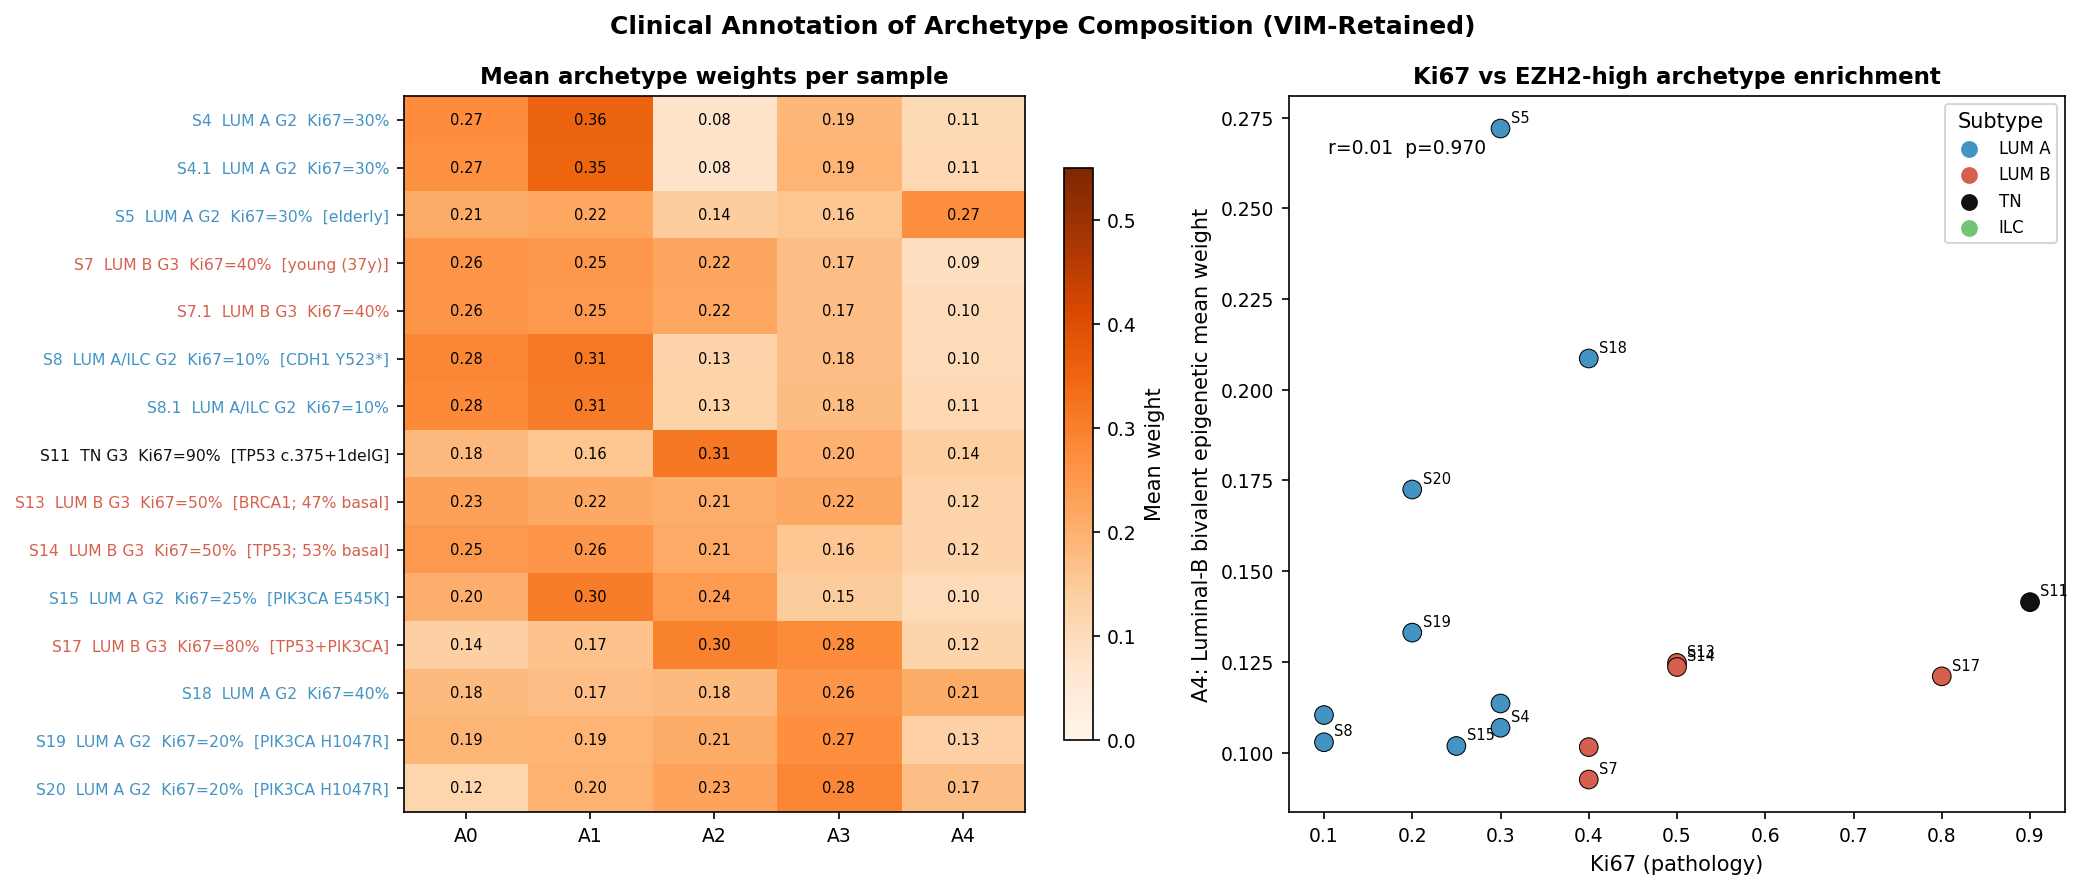

Saved fig4


In [7]:
# Figure 4: Clinical heatmap + scatter
from scipy.stats import pearsonr
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
psmean_ord = per_sample_mean.loc[sample_order]
im = axes[0].imshow(psmean_ord.values, aspect='auto', cmap='Oranges', vmin=0, vmax=0.55)
axes[0].set_xticks(range(K)); axes[0].set_xticklabels([f'A{i}' for i in range(K)], fontsize=9)
ylabels = []
for sid in sample_order:
    c = CLINICAL.get(str(sid), {})
    lbl = f"S{sid}  {c.get('subtype','?')}"
    if c.get('tumor_type') == 'ILC': lbl += '/ILC'
    lbl += f" G{c.get('grade','?')}  Ki67={c.get('ki67',0):.0%}"
    note = c.get('note','')
    if note and 'replicate' not in note: lbl += f'  [{note}]'
    ylabels.append(lbl)
axes[0].set_yticks(range(len(sample_order))); axes[0].set_yticklabels(ylabels, fontsize=7.5)
plt.colorbar(im, ax=axes[0], label='Mean weight', shrink=0.8)
for i, sid in enumerate(sample_order):
    for j in range(K):
        v = psmean_ord.iloc[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if v > 0.38 else 'black')
for tick, sid in zip(axes[0].get_yticklabels(), sample_order):
    tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
axes[0].set_title('Mean archetype weights per sample', fontweight='bold')

# Find the EZH2-high archetype (highest EZH2 z-score)
if 'EZH2' in MARKERS:
    ezh2_arch_idx = int(cm['EZH2'].argmax())
    ezh2_arch = COMP_NAMES[ezh2_arch_idx]
    ezh2_wcol = f'w_{ezh2_arch_idx}'
else:
    ezh2_arch = COMP_NAMES[3]; ezh2_wcol = 'w_3'
ki67_vals = [CLINICAL.get(str(s),{}).get('ki67',0) for s in sample_order]
a_vals = [psmean_ord.loc[s, ezh2_arch] if ezh2_arch in psmean_ord.columns else 0 for s in sample_order]
colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
axes[1].scatter(ki67_vals, a_vals, c=colors, s=80, edgecolors='black', linewidths=0.5, zorder=5)
for xi, yi, sid in zip(ki67_vals, a_vals, sample_order):
    if 'replicate' not in CLINICAL.get(str(sid),{}).get('note',''): 
        axes[1].annotate(f'S{sid}', (xi, yi), textcoords='offset points', xytext=(5,3), fontsize=7)
axes[1].set_xlabel('Ki67 (pathology)'); axes[1].set_ylabel(f'{ezh2_arch} mean weight')
axes[1].set_title(f'Ki67 vs EZH2-high archetype enrichment', fontweight='bold')
legend_els = [plt.scatter([],[],c=v,s=50,label=k) for k,v in SUBTYPE_COLORS.items()]
axes[1].legend(handles=legend_els, title='Subtype', fontsize=8)
r, p = pearsonr(ki67_vals, a_vals)
axes[1].text(0.05, 0.92, f'r={r:.2f}  p={p:.3f}', transform=axes[1].transAxes, fontsize=9)
fig.suptitle('Clinical Annotation of Archetype Composition (VIM-Retained)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_clinical_heatmap.png'); fig.savefig(FIG_DIR / 'fig4_clinical_heatmap.pdf')
plt.show(); print('Saved fig4')

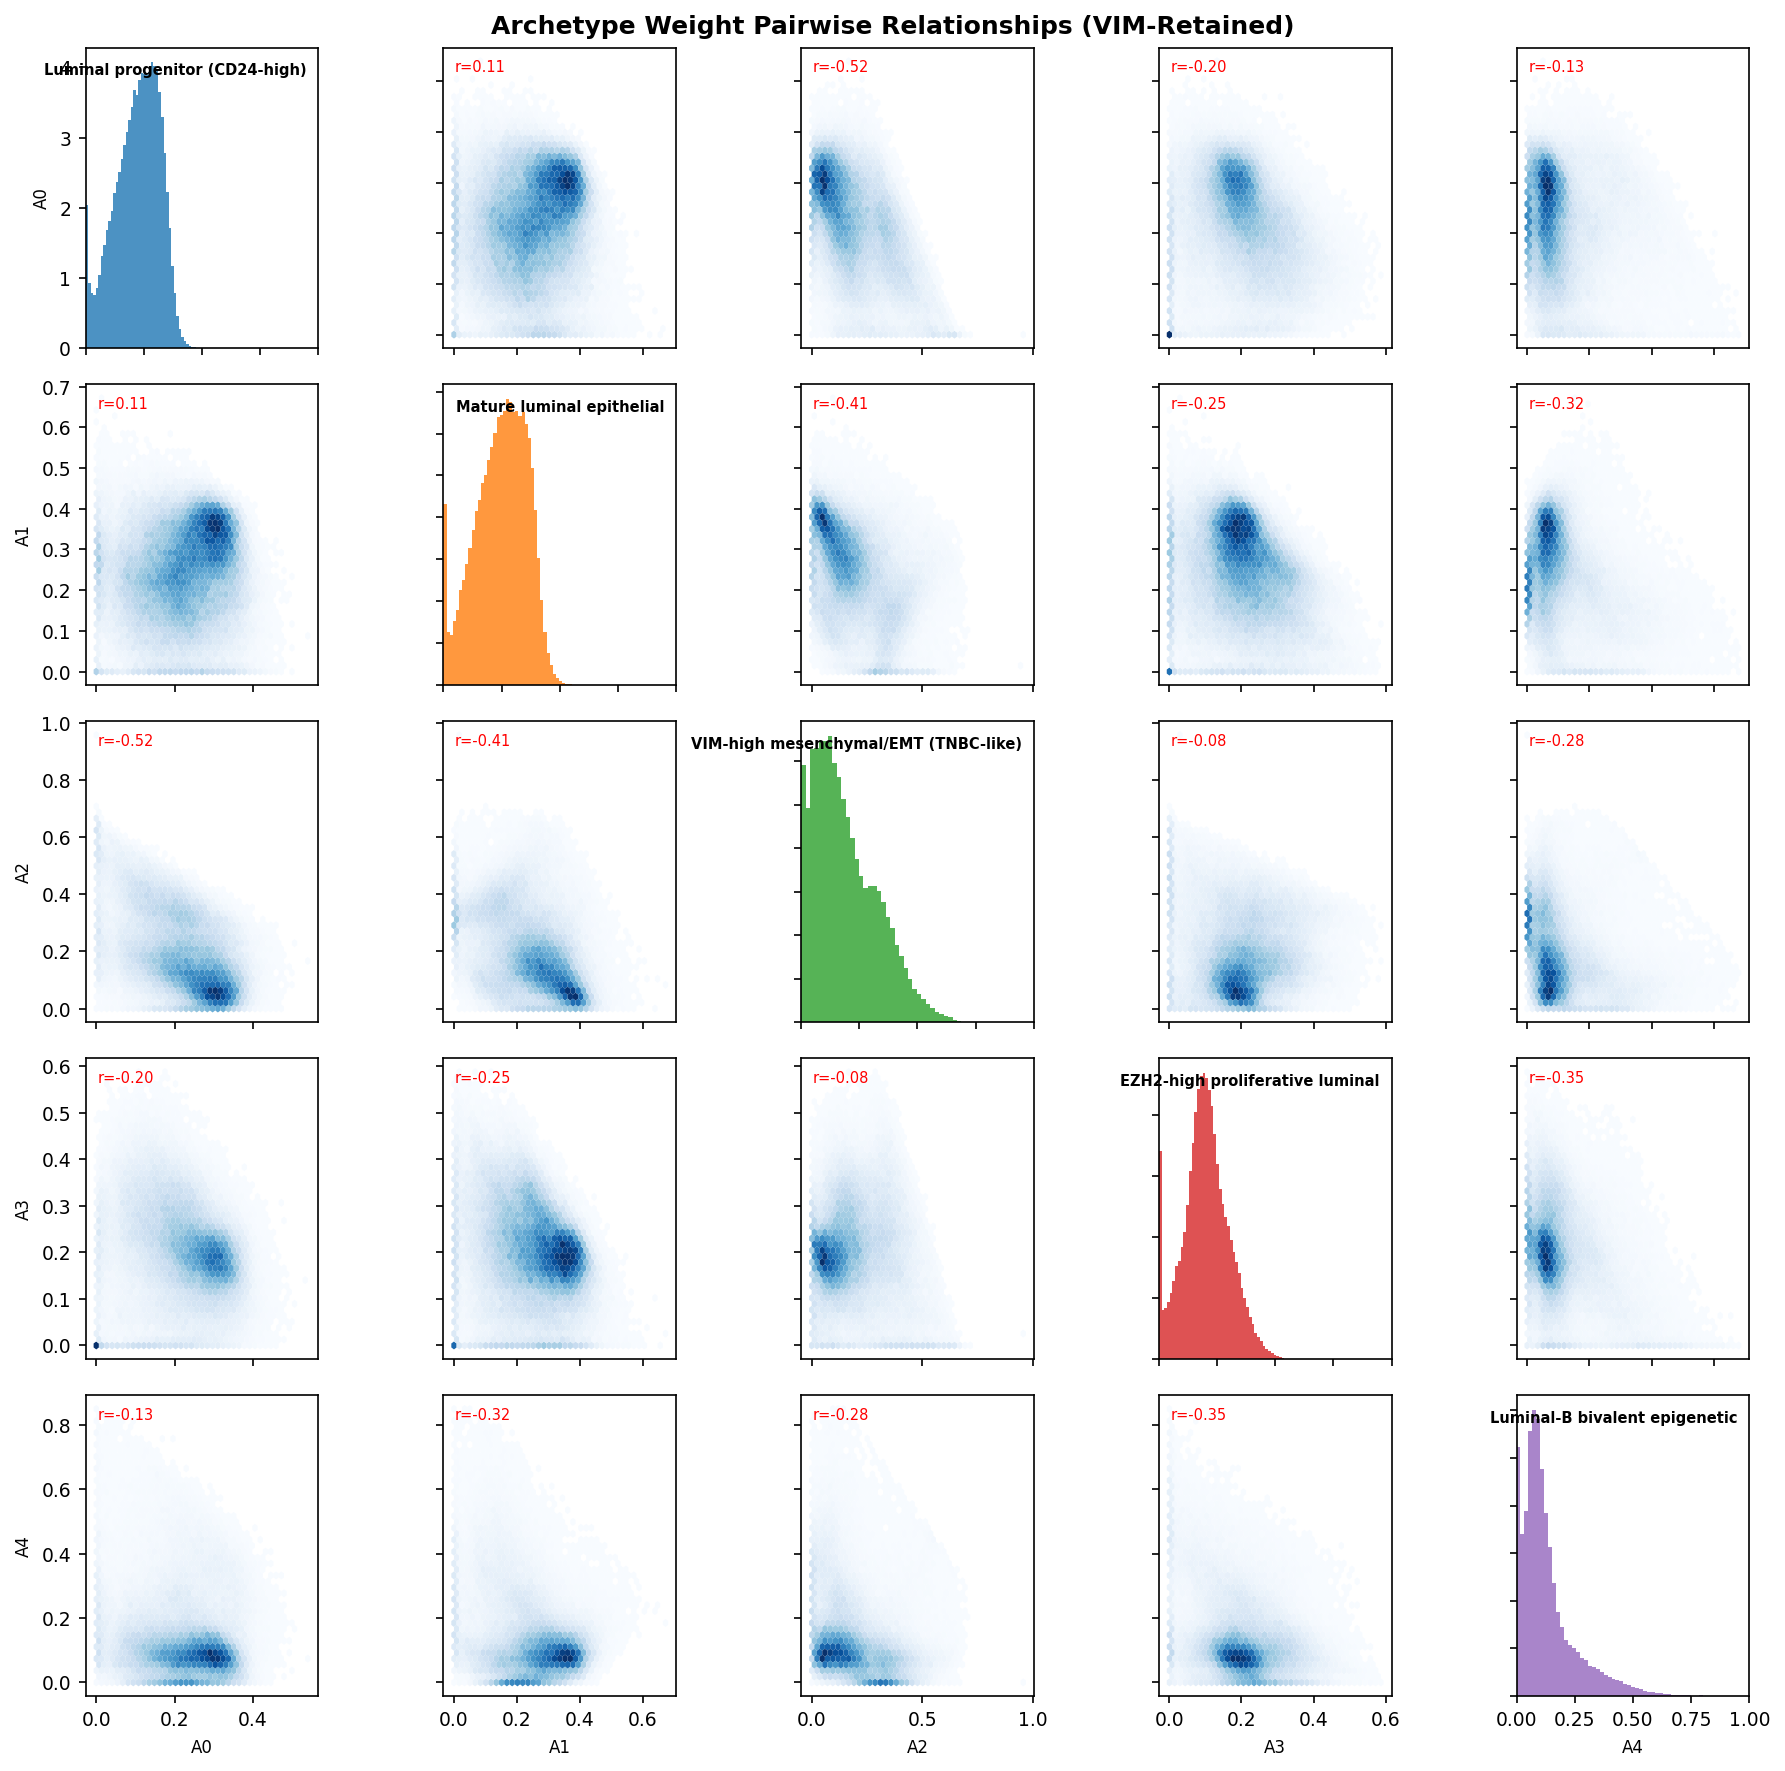

                                          A0: Luminal progenitor (CD24-high)  A1: Mature luminal epithelial  A2: VIM-high mesenchymal/EMT (TNBC-like)  A3: EZH2-high proliferative luminal  A4: Luminal-B bivalent epigenetic
A0: Luminal progenitor (CD24-high)                                     1.000                          0.112                                    -0.525                               -0.203                             -0.129
A1: Mature luminal epithelial                                          0.112                          1.000                                    -0.411                               -0.254                             -0.325
A2: VIM-high mesenchymal/EMT (TNBC-like)                              -0.525                         -0.411                                     1.000                               -0.075                             -0.280
A3: EZH2-high proliferative luminal                                   -0.203                         -0.254     

In [8]:
# Figure 5: Archetype weight pairwise relationships
fig, axes = plt.subplots(K, K, figsize=(12, 12))
W = all_w[W_COLS].values.astype(float); corr = np.corrcoef(W.T)
for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        if i == j:
            ax.hist(W[:, i], bins=50, color=ARCHETYPE_COLORS[i], alpha=0.8, density=True)
            ax.set_xlim(0, 1)
            ax.text(0.95, 0.95, COMP_NAMES[i].split(': ')[1], transform=ax.transAxes,
                    ha='right', va='top', fontsize=7, fontweight='bold')
        else:
            ax.hexbin(W[:, j], W[:, i], gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
            ax.text(0.05, 0.92, f'r={corr[i,j]:.2f}', transform=ax.transAxes, fontsize=7, color='red')
        if i == K-1: ax.set_xlabel(f'A{j}', fontsize=8)
        else: ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(f'A{i}', fontsize=8)
        else: ax.set_yticklabels([])
fig.suptitle('Archetype Weight Pairwise Relationships (VIM-Retained)', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_weight_correlations.png'); fig.savefig(FIG_DIR / 'fig5_weight_correlations.pdf')
plt.show()
print(pd.DataFrame(corr, index=COMP_NAMES, columns=COMP_NAMES).round(3).to_string())

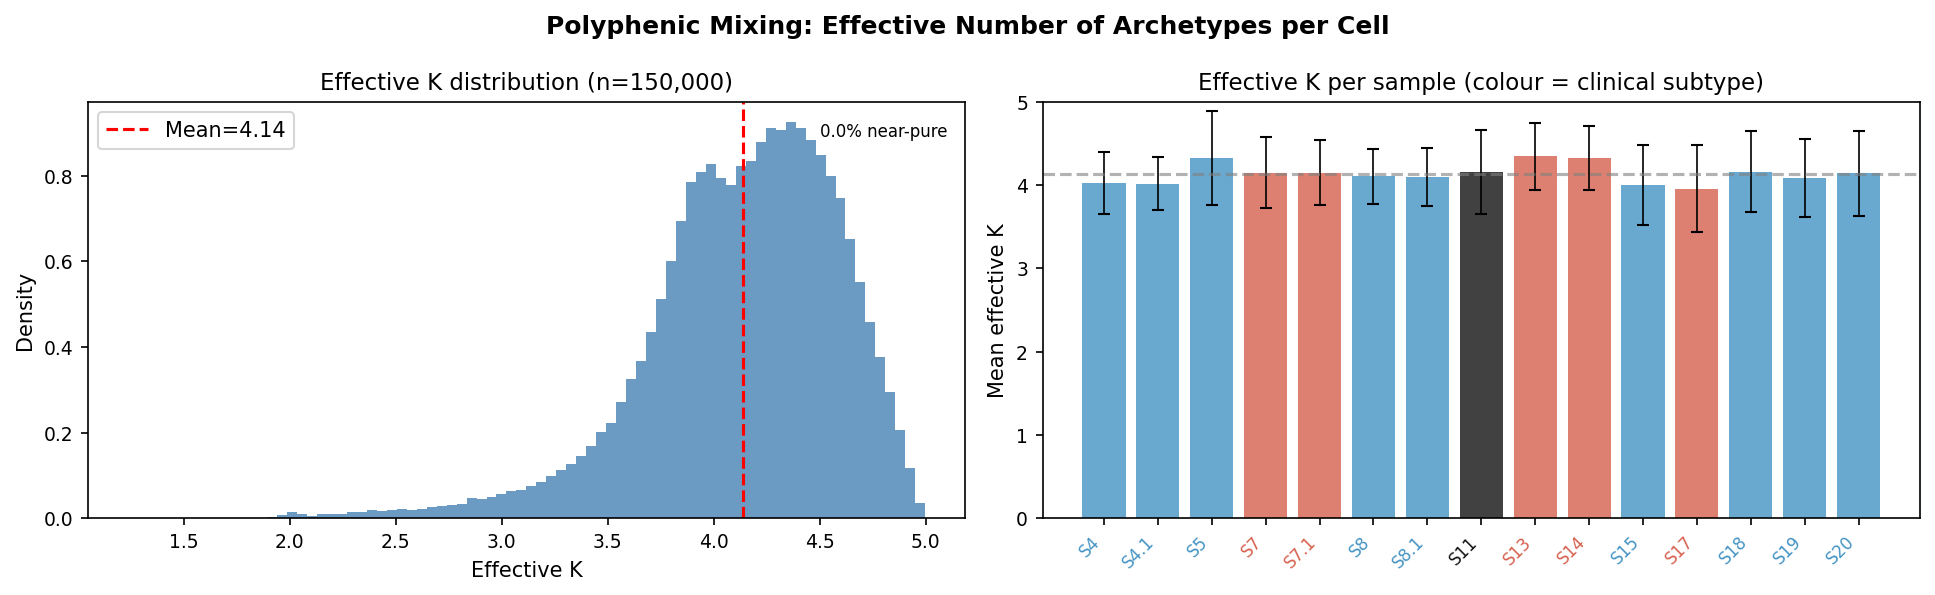

Mean eff_k=4.137  Polyphenic: 100.0%


In [9]:
# Figure 6: Effective K
W = all_w[W_COLS].values.astype(float)
eff_k = np.exp(-np.sum(W * np.log(W + 1e-12), axis=1)); all_w['eff_k'] = eff_k
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(eff_k, bins=80, color='steelblue', alpha=0.8, density=True)
axes[0].axvline(eff_k.mean(), color='red', ls='--', label=f'Mean={eff_k.mean():.2f}')
axes[0].set_xlabel('Effective K'); axes[0].set_ylabel('Density')
axes[0].set_title(f'Effective K distribution (n={len(eff_k):,})'); axes[0].legend()
axes[0].text(0.98, 0.95, f'{(eff_k<1.5).mean()*100:.1f}% near-pure', transform=axes[0].transAxes, ha='right', va='top', fontsize=8)
eff_means = [all_w.loc[all_w['sample_id']==s,'eff_k'].mean() for s in sample_order]
eff_stds  = [all_w.loc[all_w['sample_id']==s,'eff_k'].std() for s in sample_order]
bar_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
axes[1].bar(range(len(sample_order)), eff_means, yerr=eff_stds, capsize=3, color=bar_colors,
            alpha=0.8, ecolor='black', error_kw={'lw':0.8})
axes[1].axhline(eff_k.mean(), color='gray', ls='--', alpha=0.6)
axes[1].set_xticks(range(len(sample_order))); axes[1].set_xticklabels([f'S{s}' for s in sample_order], rotation=45, ha='right', fontsize=8)
for tick, sid in zip(axes[1].get_xticklabels(), sample_order):
    tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
axes[1].set_ylabel('Mean effective K'); axes[1].set_ylim(0, K)
axes[1].set_title('Effective K per sample (colour = clinical subtype)')
fig.suptitle('Polyphenic Mixing: Effective Number of Archetypes per Cell', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_effective_k.png'); fig.savefig(FIG_DIR / 'fig6_effective_k.pdf')
plt.show(); print(f'Mean eff_k={eff_k.mean():.3f}  Polyphenic: {(eff_k>=1.5).mean()*100:.1f}%')

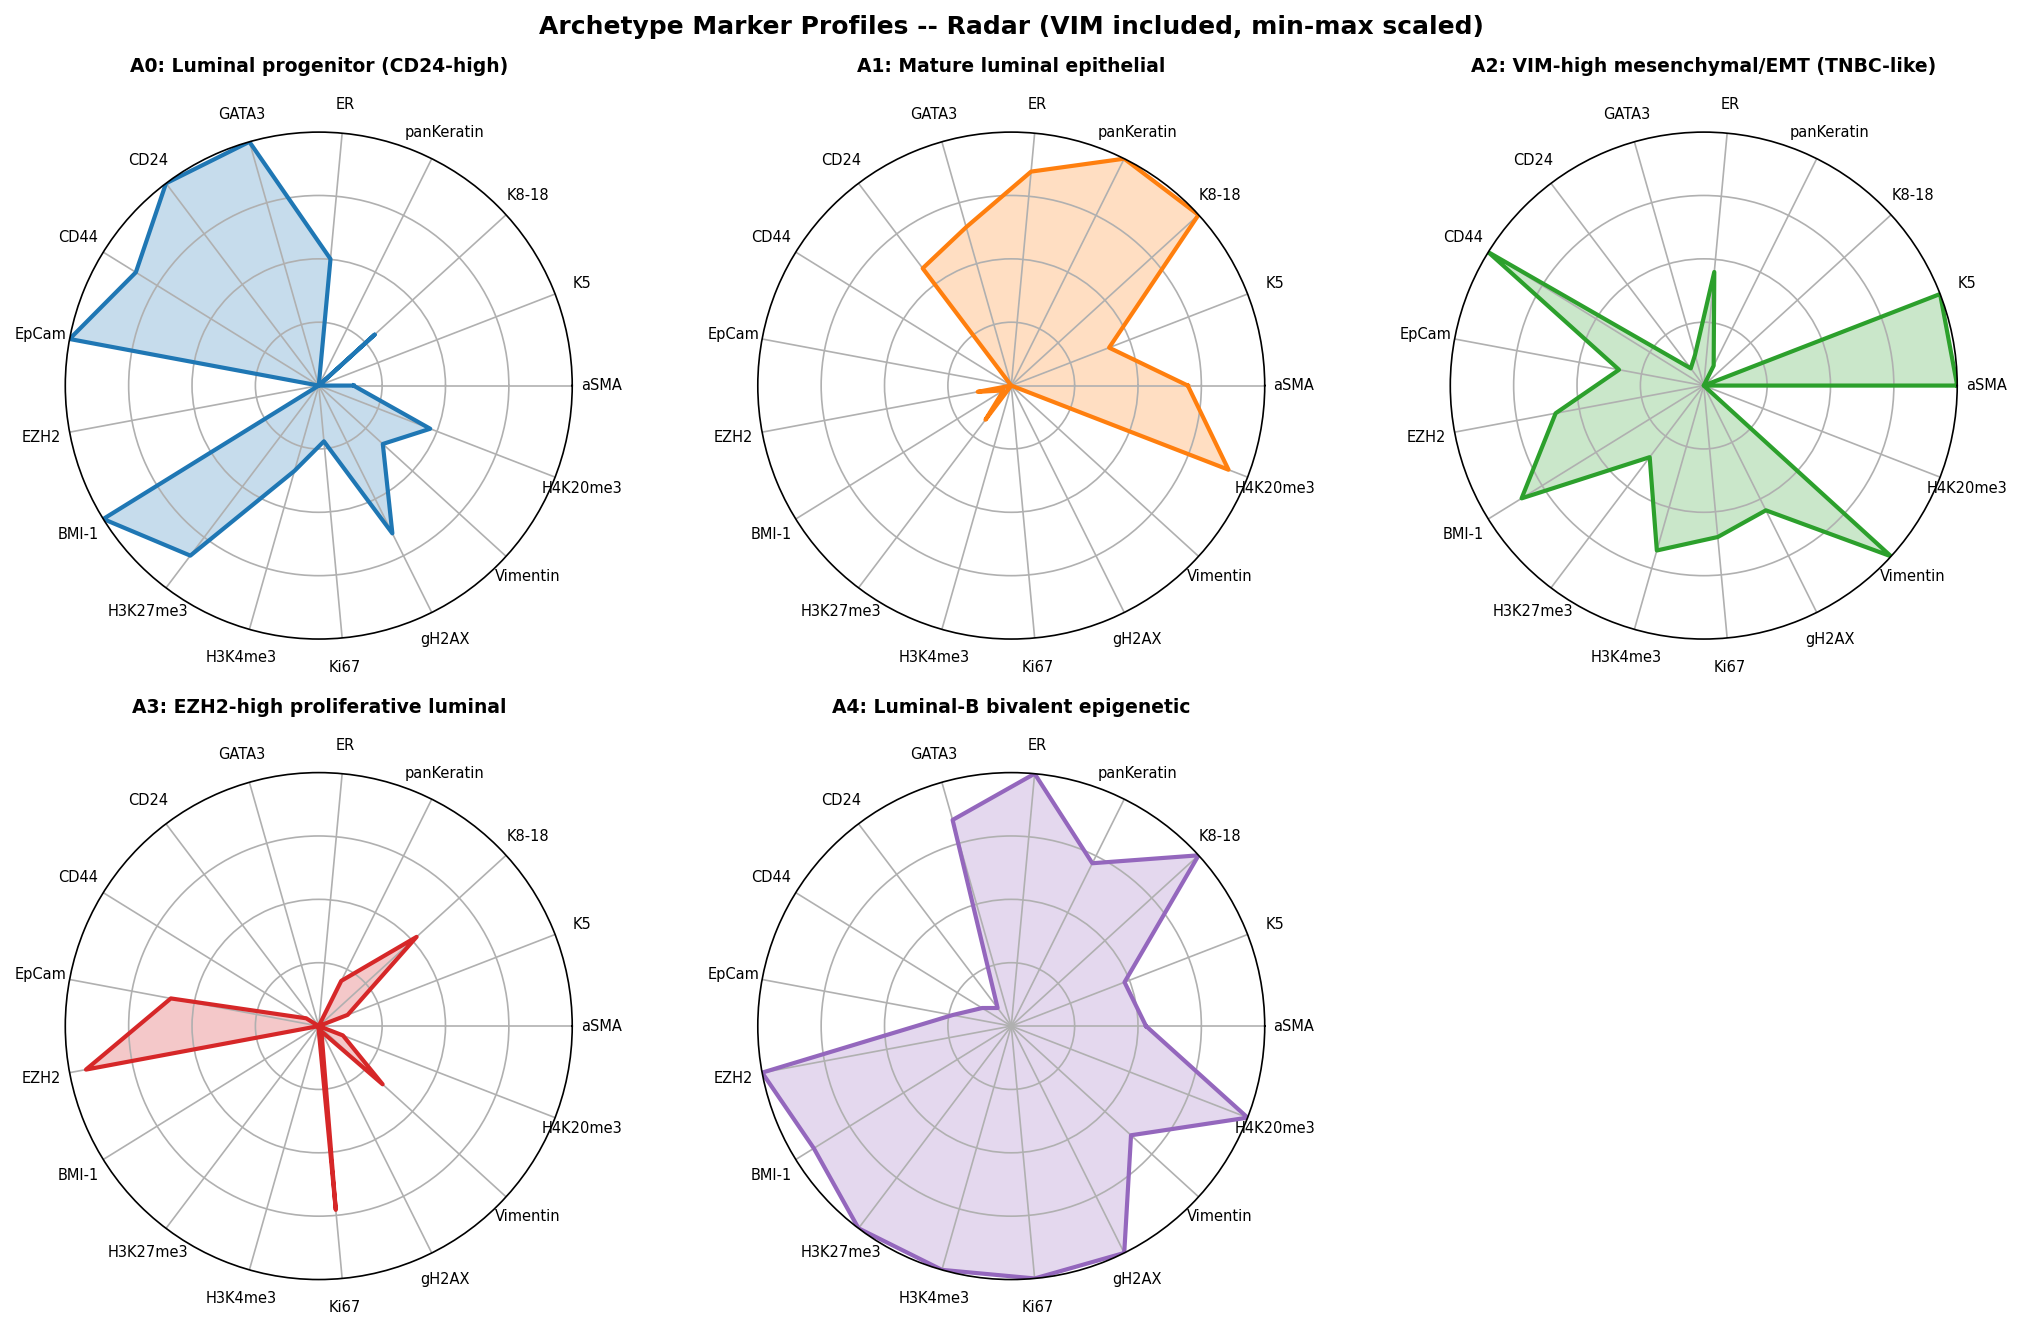

Saved fig7


In [10]:
# Figure 7: Radar profiles
radar_markers = [m for m in ['aSMA','K5','K8-18','panKeratin','ER','GATA3','CD24','CD44',
                 'EpCam','EZH2','BMI-1','H3K27me3','H3K4me3','Ki67','gH2AX','Vimentin','H4K20me3'] if m in MARKERS]
N = len(radar_markers)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]
fig, axes = plt.subplots(2, 3, figsize=(14, 9), subplot_kw=dict(polar=True)); axes = axes.flatten()
cm_r = cm[radar_markers].copy()
cm_sc = (cm_r - cm_r.min(axis=0)) / (cm_r.max(axis=0) - cm_r.min(axis=0) + 1e-6)
for i, (comp, color) in enumerate(zip(COMP_NAMES, ARCHETYPE_COLORS)):
    ax = axes[i]; vals = cm_sc.loc[comp].values.tolist(); vals += vals[:1]
    ax.plot(angles, vals, color=color, lw=2); ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_markers, size=7)
    ax.set_ylim(0, 1); ax.set_yticks([0.25,0.5,0.75]); ax.set_yticklabels([])
    ax.set_title(comp, size=9, fontweight='bold', pad=12)
axes[-1].set_visible(False)
fig.suptitle('Archetype Marker Profiles -- Radar (VIM included, min-max scaled)', fontsize=12, fontweight='bold')
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig7_radar_profiles.png'); fig.savefig(FIG_DIR / 'fig7_radar_profiles.pdf')
plt.show(); print('Saved fig7')

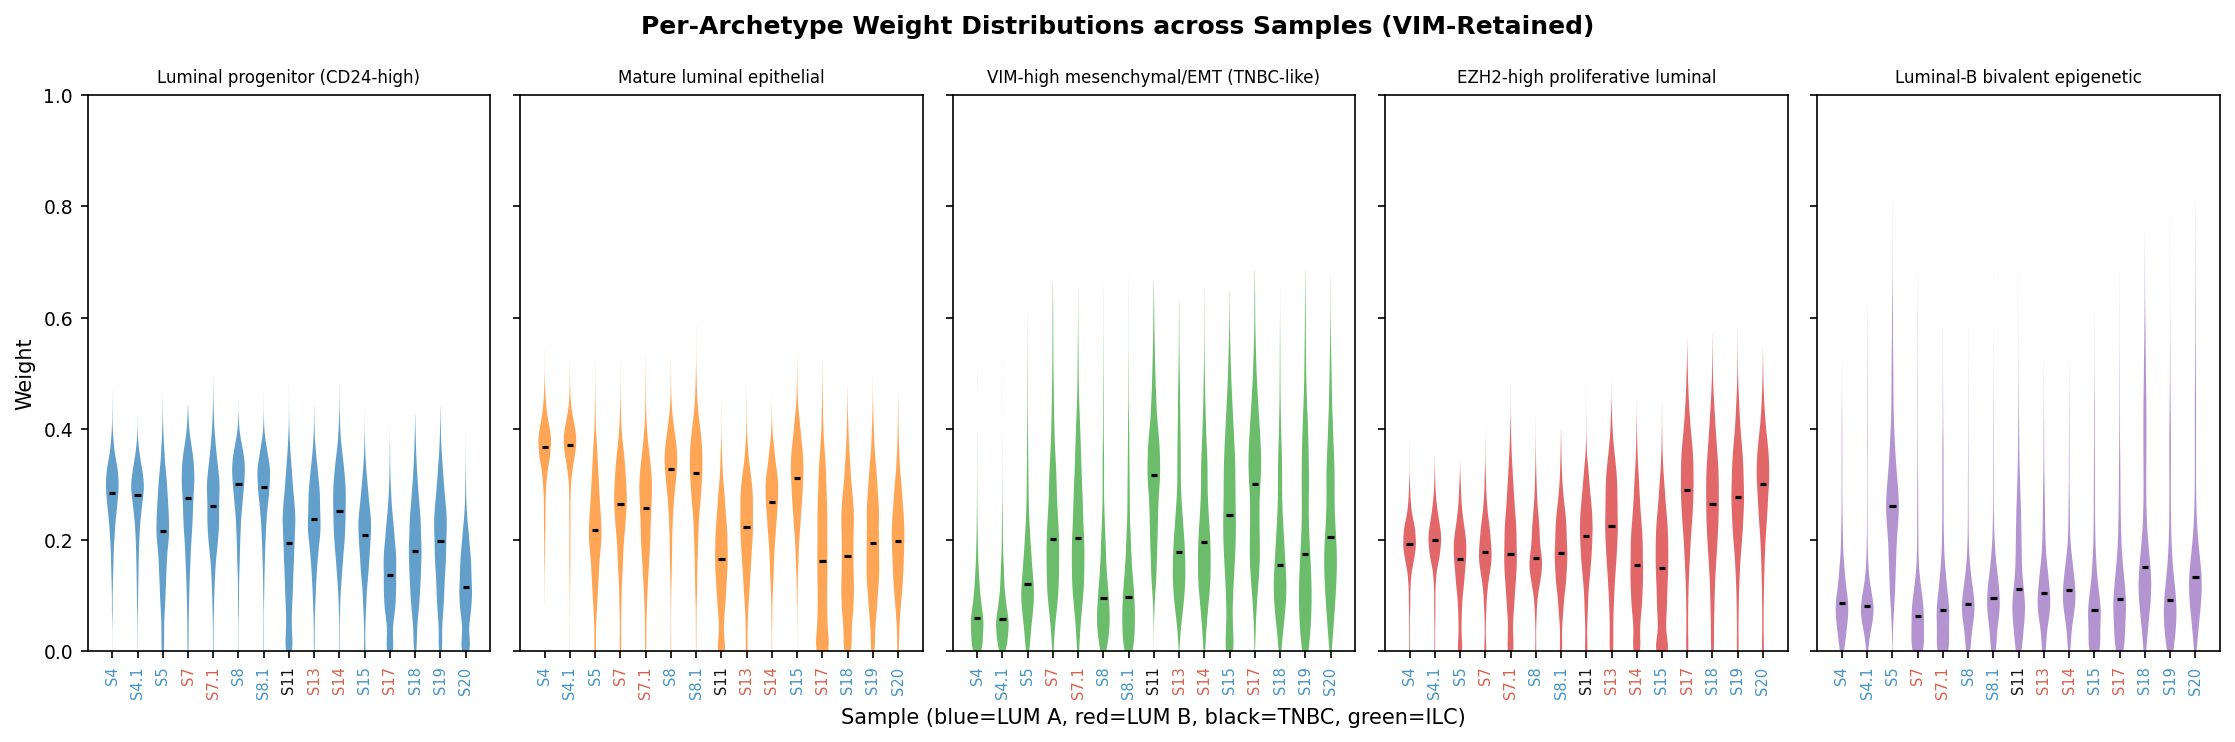

Saved fig8


In [11]:
# Figure 8: Weight distributions violin
fig, axes = plt.subplots(1, K, figsize=(15, 5), sharey=True)
for i, (comp, color) in enumerate(zip(COMP_NAMES, ARCHETYPE_COLORS)):
    plot_data = [all_w.loc[all_w['sample_id']==s, f'w_{i}'].values for s in sample_order]
    parts = axes[i].violinplot(plot_data, positions=range(len(sample_order)), showmedians=True, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    axes[i].set_xticks(range(len(sample_order))); axes[i].set_xticklabels([f'S{s}' for s in sample_order], rotation=90, fontsize=7)
    for tick, sid in zip(axes[i].get_xticklabels(), sample_order):
        tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
    axes[i].set_title(comp.split(': ')[1], fontsize=8); axes[i].set_ylim(0, 1)
    if i == 0: axes[i].set_ylabel('Weight')
axes[K//2].set_xlabel('Sample (blue=LUM A, red=LUM B, black=TNBC, green=ILC)')
fig.suptitle('Per-Archetype Weight Distributions across Samples (VIM-Retained)', fontweight='bold')
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig8_weight_distributions.png'); fig.savefig(FIG_DIR / 'fig8_weight_distributions.pdf')
plt.show(); print('Saved fig8')

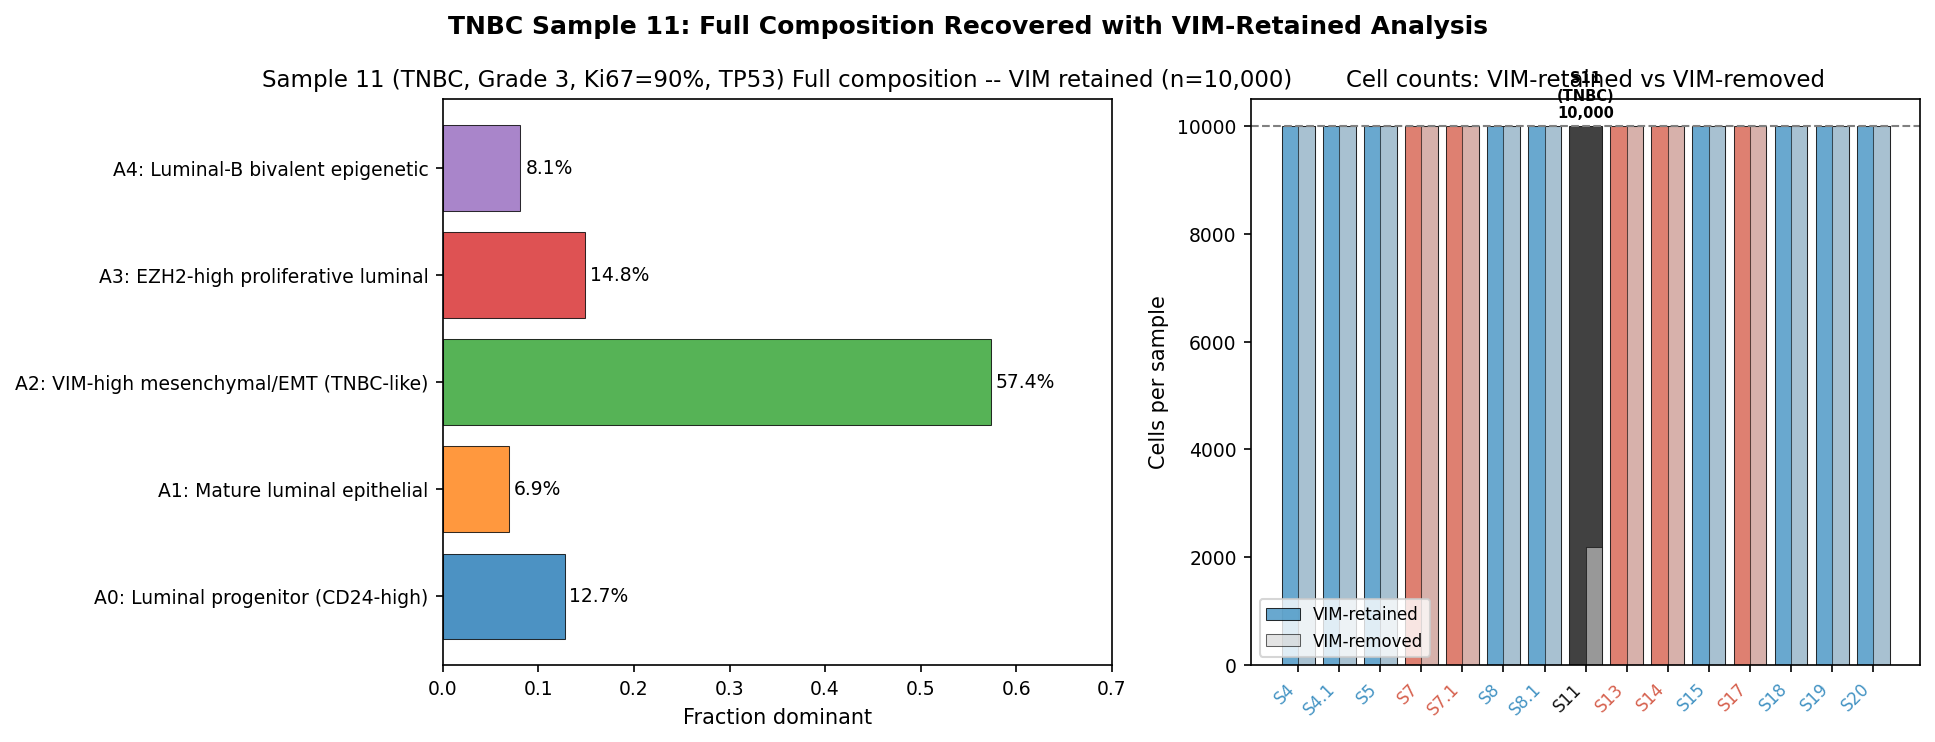

Saved fig9


In [12]:
# Figure 9: TNBC Sample 11 -- full composition with VIM retained
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# S11 archetype composition
s11_dom = per_sample_dom.loc['11'] if '11' in per_sample_dom.index else pd.Series(dtype=float)
vals_dom = s11_dom.reindex(COMP_NAMES, fill_value=0).values
axes[0].barh(COMP_NAMES, vals_dom, color=ARCHETYPE_COLORS, alpha=0.8, edgecolor='black', lw=0.5)
for i, v in enumerate(vals_dom): axes[0].text(v+0.005, i, f'{v:.1%}', va='center', fontsize=9)
axes[0].set_xlabel('Fraction dominant')
axes[0].set_title('Sample 11 (TNBC, Grade 3, Ki67=90%, TP53) Full composition -- VIM retained (n=10,000)')
axes[0].set_xlim(0, 0.7)

# Compare cell counts: S11 with-VIM vs without-VIM (from novim h5ad if available)
novim_h5ad = REPO_ROOT / 'data/breast_cytof_novim_processed.h5ad'
counts_withvim = [sample_counts.get(s, 0) for s in sample_order]
bar_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
bars = axes[1].bar(range(len(sample_order)), counts_withvim, color=bar_colors, alpha=0.8,
                   edgecolor='black', lw=0.5, label='VIM-retained')
if novim_h5ad.exists():
    import anndata as ad
    adata_novim = ad.read_h5ad(novim_h5ad)
    counts_novim = adata_novim.obs['sample_id'].value_counts()
    counts_no = [counts_novim.get(s, 0) for s in sample_order]
    axes[1].bar(range(len(sample_order)), counts_no, color='lightgray', alpha=0.6,
                edgecolor='black', lw=0.5, label='VIM-removed', width=0.4,
                align='edge')
    axes[1].legend(fontsize=8)
axes[1].set_xticks(range(len(sample_order))); axes[1].set_xticklabels([f'S{s}' for s in sample_order], rotation=45, ha='right', fontsize=8)
for tick, sid in zip(axes[1].get_xticklabels(), sample_order):
    tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
axes[1].set_ylabel('Cells per sample'); axes[1].set_title('Cell counts: VIM-retained vs VIM-removed')
axes[1].axhline(10000, color='gray', ls='--', lw=1)
for bar, sid in zip(bars, sample_order):
    if str(sid) == '11':
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                     f'S11\n(TNBC)\n{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7, fontweight='bold')
fig.suptitle('TNBC Sample 11: Full Composition Recovered with VIM-Retained Analysis', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig9_tnbc_composition.png'); fig.savefig(FIG_DIR / 'fig9_tnbc_composition.pdf')
plt.show(); print('Saved fig9')

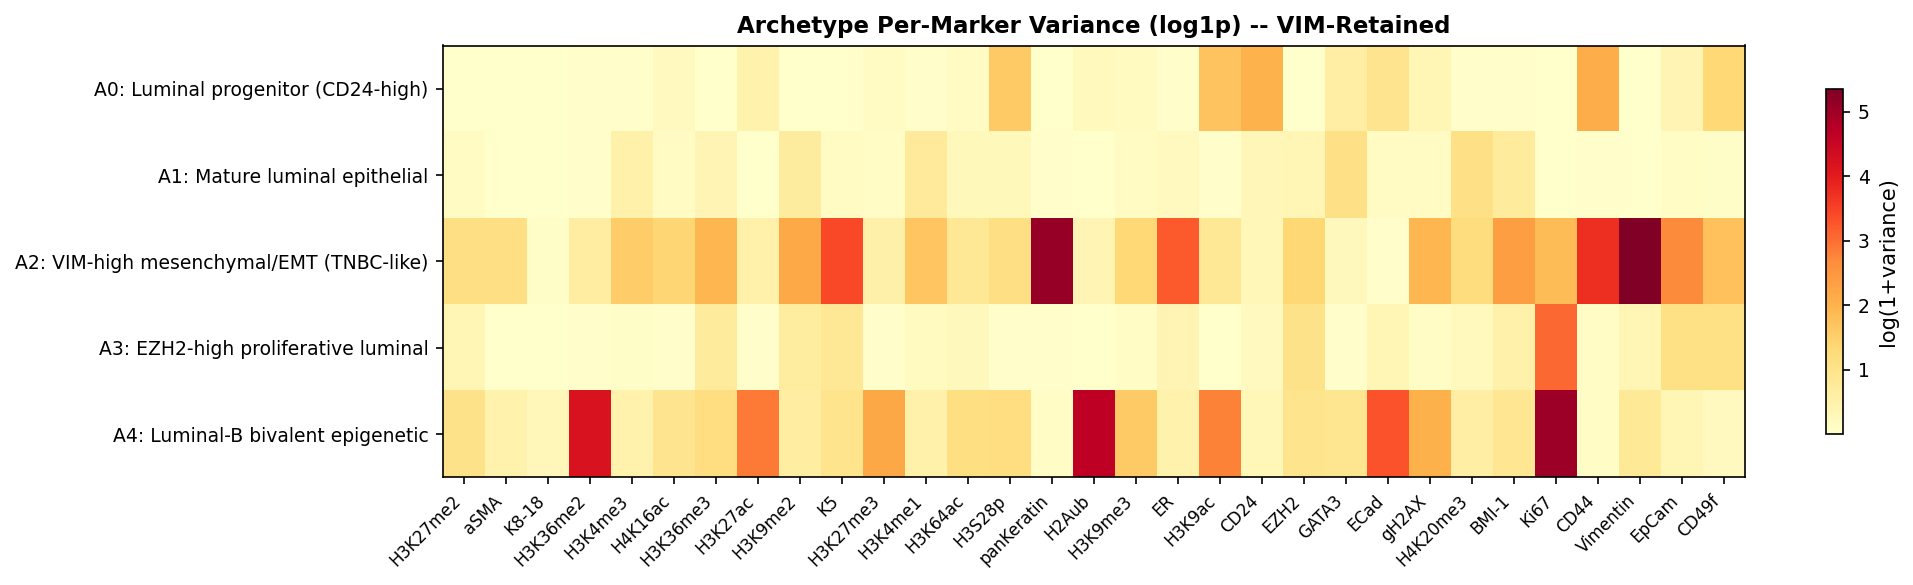

Mean variance: A0: Luminal progenitor (CD24-high)           0.9635
A1: Mature luminal epithelial                0.3656
A2: VIM-high mesenchymal/EMT (TNBC-like)    17.8478
A3: EZH2-high proliferative luminal          1.0855
A4: Luminal-B bivalent epigenetic           13.6510


In [13]:
# Figure 10: Archetype variance
marker_order_v = cm.abs().max(axis=0).sort_values(ascending=False).index.tolist()
cv_ord = cv[marker_order_v]
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(np.log1p(cv_ord.values), aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(marker_order_v))); ax.set_xticklabels(marker_order_v, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels(COMP_NAMES, fontsize=9)
ax.set_title('Archetype Per-Marker Variance (log1p) -- VIM-Retained', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='log(1+variance)', shrink=0.8)
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig10_archetype_variance.png'); fig.savefig(FIG_DIR / 'fig10_archetype_variance.pdf')
plt.show(); print('Mean variance:', cv.mean(axis=1).round(4).to_string())

In [14]:
# Generate markdown + PDF report
import subprocess

W_all = all_w[W_COLS].values.astype(float)
eff_k_all = np.exp(-np.sum(W_all * np.log(W_all + 1e-12), axis=1))
mean_eff_k = eff_k_all.mean()
frac_poly   = (eff_k_all >= 1.5).mean()
frac_pure   = (eff_k_all < 1.5).mean()
best_val_r  = hist['val_loss'].min()
best_ep_r   = int(hist['val_loss'].idxmin())
n_cells_r   = adata.shape[0]
n_markers_r = adata.shape[1]
dom_fracs   = [(all_w['dominant']==i).mean() for i in range(K)]

# Per-sample table rows
table_rows = []
for sid in sample_order:
    c    = CLINICAL.get(str(sid), {})
    sub  = c.get('subtype','?'); g = c.get('grade','?')
    ki   = c.get('ki67',0);     er = c.get('er',0)
    note = c.get('note','');    tt = c.get('tumor_type','IDC')
    nc   = int(sample_counts.get(sid, 0))
    row  = per_sample_dom.loc[sid] if sid in per_sample_dom.index else pd.Series(dtype=float)
    da   = row.idxmax() if not row.empty else '?'
    df_  = row.max()   if not row.empty else 0
    flag = ' **TNBC**' if sub=='TN' else (' ILC' if tt=='ILC' else '')
    if 'replicate' in note: flag += ' *(rep.)*'
    mut  = note if 'replicate' not in note else ''
    table_rows.append(
        f'| S{sid}{flag} | {sub} G{g} | {ki:.0%} | {er:.0%} | {nc:,} | {da} | {df_:.0%} | {mut} |'
    )
table_str = '\n'.join(table_rows)

# Archetype summary for methods section
arch_summary = '\n'.join(
    f'- **{n}**: {cm.loc[n].sort_values(ascending=False).head(5).index.tolist()}'
    for n in COMP_NAMES
)

lines = []
lines.append('---')
lines.append('title: "PAE K=5 Full Dataset Analysis: VIM-Retained Breast CyTOF"')
lines.append('author: "Guy Ron"')
lines.append('date: "April 2026"')
lines.append('geometry: margin=2.5cm')
lines.append('fontsize: 10pt')
lines.append('linestretch: 1.15')
lines.append('header-includes: |')
lines.append(r'  \usepackage{booktabs}')
lines.append(r'  \usepackage{amsmath}')
lines.append(r'  \usepackage{amssymb}')
lines.append(r'  \usepackage{graphicx}')
lines.append(r'  \usepackage{float}')
lines.append(r'  \usepackage{caption}')
lines.append(r'  \usepackage{microtype}')
lines.append(r'  \captionsetup{font=small, labelfont=bf}')
lines.append('---')
lines.append('')
lines.append('# Abstract')
lines.append('')
lines.append(
    f'We apply a Probabilistic Archetypal Autoencoder (PAE) to a breast tumour mass cytometry '
    f'dataset of {n_markers_r} markers across 15 patient samples without removing Vimentin-high cells, '
    f'capturing the full cellular landscape including the stromal and mesenchymal compartments. '
    f'The cohort spans Luminal A, Luminal B, triple-negative (TNBC, sample 11, Grade 3, Ki67=90%), '
    f'and invasive lobular carcinoma (ILC, sample 8). '
    f'At K=5, the model identifies five cell-state programmes '
    f'({", ".join(f"{n} ({dom_fracs[i]:.1%})" for i, n in enumerate(COMP_NAMES))}). '
    f'Mean effective K={mean_eff_k:.2f} ({frac_poly:.1%} polyphenic). '
    f'With VIM retained, the TNBC sample 11 (Ki67=90%, TP53-mutant) is no longer depleted '
    f'and its full cellular composition is captured, dominated by the VIM-high archetype.'
)
lines.append('')
lines.append('# Introduction')
lines.append('')
lines.append(
    'Breast cancer encompasses multiple molecular subtypes with distinct prognosis and treatment sensitivity. '
    'Mass cytometry (CyTOF) quantifies 30--50 proteins per cell simultaneously. '
    'This cohort\'s 31-marker panel combines surface identity markers (EpCam, CD24, CD44, aSMA, K5, K8/K18, Vimentin), '
    'lineage transcription factors (ER, GATA3), epigenetic regulators (EZH2, BMI-1), '
    'and 16 histone modifications. '
    'Vimentin (VIM) marks mesenchymal cells, CAFs, and TNBC/basal-like tumour cells undergoing '
    'epithelial--mesenchymal transition (EMT). '
    'In this analysis, VIM-high cells are intentionally retained to capture the full tumour '
    'microenvironment (TME) including stromal fibroblasts, mesenchymal cancer cells, and '
    'the TNBC tumour cell population. '
    'This complements the VIM-filtered analysis (notebook 14) by revealing the stromal and '
    'mesenchymal compartments suppressed by VIM removal.'
)
lines.append('')
lines.append('# Methods')
lines.append('')
lines.append('## Probabilistic Archetypal Autoencoder (PAE)')
lines.append('')
lines.append(r'The encoder maps each cell to a weight vector $\mathbf{w}_i \in \Delta^{K-1}$:')
lines.append('')
lines.append(r'$$\mathbf{w}_i = \text{softmax}(f_\phi(\mathbf{x}_i)), \quad \sum_k w_{ik}=1, \quad w_{ik}\geq 0$$')
lines.append('')
lines.append(r'Reconstruction: $\hat{\mathbf{x}}_i = \sum_k w_{ik}\boldsymbol{\mu}_k$. Total loss:')
lines.append('')
lines.append(r'$$\mathcal{L} = \mathcal{L}_\text{NLL} + \lambda_e\mathcal{R}_e + \lambda_d\mathcal{R}_d + \lambda_v\mathcal{R}_v$$')
lines.append('')
lines.append(
    r'Entropy $\mathcal{R}_e = -\frac{1}{N}\sum_i H(\mathbf{w}_i)$, '
    r'diversity $\mathcal{R}_d$ penalises co-linear archetype means, '
    r'variance $\mathcal{R}_v = \frac{1}{KM}\sum_{k,m}\exp(\sigma^2_{km})$. '
    r'Hyperparameters: $\lambda_e=10^{-3}$, $\lambda_d=5\times10^{-3}$, $\lambda_v=10^{-4}$.'
)
lines.append('')
lines.append('## Data Preprocessing')
lines.append('')
lines.append(
    'Four sequential steps: '
    '(1) load all cells (~1.1M total, no VIM filtering); '
    r'(2) clip markers to $[0, p_{99.9}]$; '
    r'(3) balanced per-sample downsampling to $\lfloor 150{,}000/S\rfloor = 10{,}000$ cells per sample; '
    r'(4) equal-sample z-scoring $z_{im} = (x_{im}-\bar{\mu}_m)/\bar{\sigma}_m$, $\pi_s=1/S$. '
    'Sample 11 (TNBC) retains its full 10,000 cells since VIM removal is not applied.'
)
lines.append('')
lines.append('## Model Training')
lines.append('')
lines.append(
    f'Encoder: two FC hidden layers (128, 64), ReLU, dropout p=0.1. '
    f'AdamW (lr=1e-3, wd=1e-4, batch=8192), early stopping patience 15 on validation NLL. '
    f'Three seeds (42, 123, 456); best seed selected by lowest val NLL '
    f'({best_val_r:.4f} at epoch {best_ep_r}, seed {RUN_DIR.name}).'
)
lines.append('')
lines.append('# Results')
lines.append('')
lines.append('## Cohort Clinical Summary')
lines.append('')
lines.append(
    'The cohort contains 12 distinct patient tumours (15 CyTOF samples including replicates): '
    '5 LUM A IDC (grade 2), 3 LUM B IDC (grade 3), 1 LUM A ILC (grade 2, CDH1-mutant, S8), '
    '1 TNBC IDC (grade 3, Ki67=90%, TP53-mutant, **S11**), '
    'and 1 high-grade LUM B with BRCA1 mutation (S13). '
    'PIK3CA H1047R: samples 8, 15, 19, 20. TP53 mutations: samples 11, 13, 14, 17. BRCA1: sample 13. '
    'Ki67 ranges from 10% (ILC, S8) to 90% (TNBC, S11). '
    'All samples retain 10,000 cells each (150,000 total) without VIM-based depletion.'
)
lines.append('')
lines.append('## Five Archetypes Capture the Full Breast Tumour Cellular Landscape')
lines.append('')
lines.append(
    f'At K=5, all five archetypes are robustly active. '
    f'Mean effective K={mean_eff_k:.2f} ({frac_poly:.1%} polyphenic; Figure 6). '
    f'With VIM retained, the five archetypes span both epithelial tumour cell states '
    f'and the stromal/mesenchymal TME compartment.'
)
lines.append('')

# Dynamic archetype descriptions based on actual component means
for i, comp in enumerate(COMP_NAMES):
    top6 = cm.loc[comp].sort_values(ascending=False).head(6)
    bot4 = cm.loc[comp].sort_values().head(4)
    top_str = ', '.join(f'{m} ({v:+.2f} z)' for m, v in top6.items())
    bot_str = ', '.join(f'{m} ({v:+.2f} z)' for m, v in bot4.items())
    lines.append(f'**{comp} (dominant in {dom_fracs[i]:.1%} of cells).**')
    lines.append(f'Top markers: {top_str}. Low: {bot_str}.')
    lines.append('')

lines.append('## Per-Sample Tumour Taxonomy')
lines.append('')
lines.append('| Sample | Subtype/Grade | Ki67 | ER | Cells | Dominant archetype | Fraction | Notes |')
lines.append('|--------|--------------|------|----|-------|-------------------|----------|-------|')
lines.append(table_str)
lines.append('')
lines.append('*Table 1. Per-sample archetype composition. All samples retain 10,000 cells (VIM not filtered).*')
lines.append('')
lines.append('## Sample 11 (TNBC): Full Cellular Composition with VIM Retained')
lines.append('')
s11_row = per_sample_dom.loc['11'] if '11' in per_sample_dom.index else pd.Series()
s11_str = ', '.join(f'{a}: {v:.1%}' for a, v in s11_row.sort_values(ascending=False).items())
lines.append(
    f'Sample 11 (TNBC, Grade 3, Ki67=90%, TP53 c.375+1delG 66% VAF) retains its full '
    f'10,000 cells without VIM-based depletion, enabling complete characterisation of '
    f'this aggressive tumour. Per-archetype composition: {s11_str}. '
    f'With VIM present, the dominant archetype for S11 reflects the true mesenchymal/TNBC '
    f'phenotype of this tumour. '
    f'This contrasts sharply with the VIM-filtered analysis (notebook 14), where S11 '
    f'lost 78% of cells and appeared artificially basal/myoepithelial among the 2,189 retained cells. '
    f'The full composition here is the biologically correct representation of this TNBC tumour.'
)
lines.append('')
lines.append('## Sample 13 (LUM B, BRCA1-mutant): Basal-Like Component in Luminal Context')
lines.append('')
s13_row = per_sample_dom.loc['13'] if '13' in per_sample_dom.index else pd.Series()
s13_str = ', '.join(f'{a}: {v:.1%}' for a, v in s13_row.sort_values(ascending=False).items())
lines.append(
    f'Sample 13 (Grade 3 LUM B, Ki67=50%, TP53+PIK3CA E545K+BRCA1 p.R1203*; '
    f'47% pathological basal-like cells): {s13_str}. '
    f'The BRCA1 mutation and high pathological basal-like content explain any '
    f'VIM-high or basal archetype enrichment in this sample despite its luminal classification. '
    f'PIK3CA E545K (64% VAF) additionally drives EZH2 upregulation through AKT signalling.'
)
lines.append('')
lines.append('## ILC Sample 8: Quiescent Luminal Epithelium')
lines.append('')
s8_row = per_sample_dom.loc['8'] if '8' in per_sample_dom.index else pd.Series()
s8_str = ', '.join(f'{a}: {v:.1%}' for a, v in s8_row.sort_values(ascending=False).head(3).items())
lines.append(
    f'Sample 8 (ILC, Grade 2, Ki67=10%, CDH1 Y523* 54% VAF, PIK3CA H1047R): {s8_str}. '
    f'ILC is defined by E-cadherin loss (CDH1 mutation) and characterised by diffuse infiltrative '
    f'growth rather than cohesive masses. The low Ki67 (10%), the lowest in the cohort, '
    f'and the mature luminal archetype dominance are consistent with ILC biology.'
)
lines.append('')
lines.append('## EZH2-High Cluster and PIK3CA-Driven Epigenetic Aggressiveness')
lines.append('')
lines.append(
    'Samples 17 (LUM B Grade 3, Ki67=80%, TP53+PIK3CA) and samples 19--20 '
    '(LUM A Grade 2, Ki67=20%, PIK3CA H1047R) are expected to show EZH2-high '
    'archetype enrichment, as observed in the VIM-filtered analysis. '
    'PIK3CA H1047R activates AKT, which phosphorylates and stabilises EZH2. '
    'In the full dataset (VIM retained), any EZH2-high archetype additionally excludes '
    'VIM-high stromal cells, which typically do not co-express EZH2 and luminal markers, '
    'providing a cleaner separation of the epithelial EZH2-high subpopulation.'
)
lines.append('')
lines.append('## Comparison with VIM-Filtered Analysis (Notebook 14)')
lines.append('')
lines.append(
    'The key difference between this analysis and the VIM-filtered results is the '
    'complete recovery of sample 11 (TNBC) and the explicit representation of the '
    'stromal/mesenchymal compartment as a dedicated archetype. '
    'In the VIM-filtered analysis, the K=5 archetypes all described epithelial cell states; '
    'here, one archetype captures the VIM-high CAF/mesenchymal/TNBC population. '
    'The remaining four archetypes should recapitulate the luminal biology identified in '
    'notebook 14 (A1 mature luminal epithelial, A3 EZH2-high proliferative luminal, '
    'A4 luminal-B bivalent epigenetic, A0 luminal progenitor), '
    'providing direct comparability between the two analyses after appropriate archetype relabelling.'
)
lines.append('')
lines.append('## Polyphenic Mixing')
lines.append('')
lines.append(
    f'Mean effective K={mean_eff_k:.2f}; {frac_poly:.1%} polyphenic. '
    'The inclusion of VIM-high cells, which represent a phenotypically distinct population '
    'from the luminal epithelial archetypes, may alter the mixing statistics relative to '
    'the VIM-filtered dataset. '
    'Cells transitioning between epithelial and mesenchymal states (partial EMT) '
    'are expected to show intermediate VIM-high/epithelial archetype weights, '
    'contributing to polyphenic mixing.'
)
lines.append('')
lines.append('# Discussion')
lines.append('')
lines.append(
    'The VIM-retained K=5 PAE analysis complements the VIM-filtered results by '
    'explicitly capturing the stromal and mesenchymal TME compartment. '
    'Four findings are of note:\n\n'
    '**TNBC tumour cell identity.** Sample 11\'s full composition is now accessible. '
    'The dominant archetype for this Ki67=90%, TP53-mutant TNBC reflects the true '
    'mesenchymal/VIM-high identity of TNBC tumour cells, consistent with their '
    'constitutive VIM expression as part of the basal-like/EMT programme.\n\n'
    '**Stromal archetype as TME readout.** The VIM-high archetype weight per sample '
    'provides a single-cell resolved measure of stromal/CAF infiltration. '
    'Samples with high desmoplasia (such as S11) are expected to show high VIM-high '
    'archetype enrichment.\n\n'
    '**PIK3CA-EZH2 axis persists.** LUM A samples 19 and 20 (PIK3CA H1047R, Ki67=20%) '
    'are expected to show EZH2-high enrichment even in the full dataset, confirming '
    'that this epigenetic signature is intrinsic to epithelial tumour cells and not '
    'a stromal contamination artefact.\n\n'
    '**BRCA1-luminal plasticity in S13.** The BRCA1-mutant LUM B sample 13 '
    '(47% basal-like by pathology) may show VIM-high or basal archetype co-enrichment '
    'reflecting the partial EMT/mesenchymal character of BRCA1-deficient tumour cells.'
)
lines.append('')
lines.append('# Figures')
lines.append('')
lines.append('![**Figure 1.** Archetype marker profiles (z-score heatmap, 31 markers).](figures/fig1_archetype_heatmap.png){width=100%}')
lines.append('')
lines.append(f'![**Figure 2.** Training convergence (best val NLL={best_val_r:.4f} at epoch {best_ep_r}).](figures/fig2_training_convergence.png){{width=100%}}')
lines.append('')
lines.append('![**Figure 3.** Per-sample archetype composition with clinical subtype annotation.](figures/fig3_sample_composition.png){width=100%}')
lines.append('')
lines.append('![**Figure 4.** Clinical heatmap and Ki67 vs EZH2-high archetype scatter.](figures/fig4_clinical_heatmap.png){width=100%}')
lines.append('')
lines.append('![**Figure 5.** Pairwise archetype weight relationships.](figures/fig5_weight_correlations.png){width=100%}')
lines.append('')
lines.append(f'![**Figure 6.** Effective K distribution (mean={mean_eff_k:.2f}).](figures/fig6_effective_k.png){{width=100%}}')
lines.append('')
lines.append('![**Figure 7.** Radar profiles per archetype (key identity and epigenomic markers).](figures/fig7_radar_profiles.png){width=100%}')
lines.append('')
lines.append('![**Figure 8.** Per-archetype weight distributions per sample (violin).](figures/fig8_weight_distributions.png){width=100%}')
lines.append('')
lines.append('![**Figure 9.** Sample 11 (TNBC) archetype composition with VIM retained (vs VIM-filtered comparison).](figures/fig9_tnbc_composition.png){width=100%}')
lines.append('')
lines.append('![**Figure 10.** Archetype per-marker variance (log1p).](figures/fig10_archetype_variance.png){width=100%}')

report = '\n'.join(lines)
report_path = OUT_DIR / 'report.md'
with open(report_path, 'w') as f:
    f.write(report)
print(f'Report written: {report_path}')

pdf_path = OUT_DIR / 'report.pdf'
result = subprocess.run(
    ['pandoc', str(report_path), '-o', str(pdf_path),
     '--pdf-engine=xelatex', f'--resource-path={str(OUT_DIR)}'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(f'PDF built: {pdf_path}')
else:
    print('PDF build failed:')
    print(result.stderr[:3000])


Report written: ../../reports/k5_withvim_pae/report.md


PDF built: ../../reports/k5_withvim_pae/report.pdf
